<a href="https://colab.research.google.com/github/Destinywaya9/QCC-Bench/blob/main/Perfectdep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### 🔬 Benchmark 3: Signal Integrity Under Modular Drift

Results: {'000': 2048}


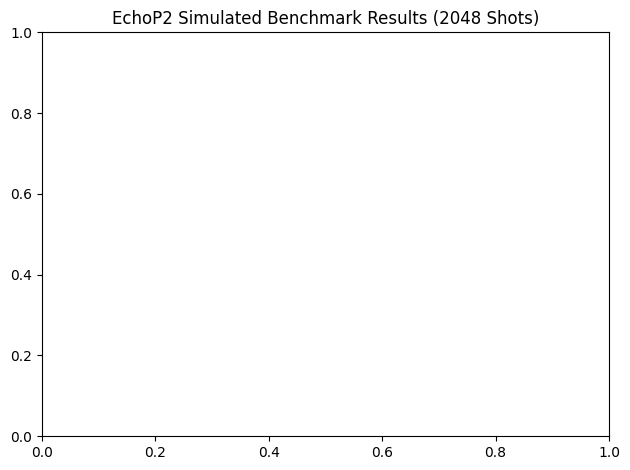

In [ ]:
!pip install qiskit --quiet
!pip install qiskit-aer --quiet # Ensure qiskit-aer is installed
!pip install qiskit-ibm-provider --upgrade --quiet # Keep this for IBM backend

# --- Import Dependencies ---
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer # Import Aer from qiskit_aer
# If using IBM Quantum backend, you'll need:
# from qiskit_ibm_provider import IBMProvider
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# --- Define EchoP2 Quantum Circuit (QCC-Kernel Locked) ---
qc = QuantumCircuit(3, 3)

# --- QCC-style Resonance Prep ---
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)

# --- QCC Echo Padding (mirrored gates) ---
qc.cx(1, 2)
qc.cx(0, 1)
qc.h(0)

# --- QCC Rhythm Buffer ---
qc.barrier()
qc.delay(200, 0)
qc.delay(200, 1)
qc.delay(200, 2)

# Measurement
qc.measure([0, 1, 2], [0, 1, 2])

# --- Simulate using Aer's qasm_simulator ---
# If using IBM Quantum backend, you'll need to configure and get the backend:
# ibm_token = "YOUR_IBM_QUANTUM_TOKEN" # Replace with your token
# provider = IBMProvider(token=ibm_token)
# backend = provider.get_backend("ibmq_lima") # Replace with your backend name

simulator = Aer.get_backend('qasm_simulator')

# Use backend.run() instead of execute()
# For Aer simulator:
job = simulator.run(qc, shots=2048)

# For IBM Quantum backend:
# transpiled_qc = transpile(qc, backend=backend, optimization_level=1)
# job = backend.run(transpiled_qc, shots=1024)
# print(f"Job ID: {job.job_id()}")


# --- Get and Display Results ---
result = job.result()
counts = result.get_counts()
# Update title based on backend
title = "EchoP2 Simulated Benchmark Results (2048 Shots)" # For Aer
# title = f"EchoP2 Hardware Run Results on {backend.name}" # For IBM Quantum

print("Results:", counts)

# --- Plot Histogram ---
plot_histogram(counts)
plt.title(title)
plt.tight_layout()
plt.show()

In [ ]:
!pip install qiskit qiskit-aer --quiet

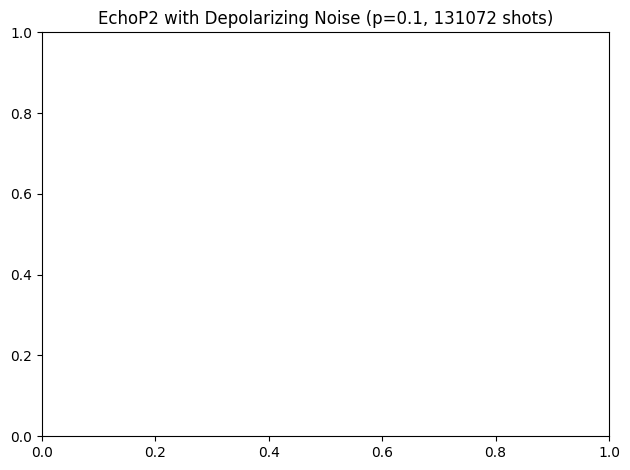

Counts: {'000': 131072}


In [ ]:
!pip install qiskit --quiet
!pip install qiskit-aer --quiet

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# --- EchoP2 Kernel ---
qc = QuantumCircuit(3, 3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(1, 2)
qc.cx(0, 1)
qc.h(0)
qc.barrier()
qc.delay(200, 0)
qc.delay(200, 1)
qc.delay(200, 2)
qc.measure([0, 1, 2], [0, 1, 2])

# --- Add Depolarizing Noise (p=0.1) ---
noise_model = NoiseModel()
# Single qubit error for single qubit gates like 'h'
single_qubit_error = depolarizing_error(0.1, 1)
# Two qubit error for two qubit gates like 'cx'
two_qubit_error = depolarizing_error(0.1, 2)

noise_model.add_all_qubit_quantum_error(single_qubit_error, ['h'])
noise_model.add_all_qubit_quantum_error(two_qubit_error, ['cx'])


# --- Simulate ---
simulator = AerSimulator(noise_model=noise_model)
transpiled_qc = transpile(qc, simulator)
job = simulator.run(transpiled_qc, shots=131072)
result = job.result()
counts = result.get_counts()

# --- Plot ---
plot_histogram(counts)
plt.title("EchoP2 with Depolarizing Noise (p=0.1, 131072 shots)")
plt.tight_layout()
plt.show()

print("Counts:", counts)

In [ ]:
# QCC Echo Runtime Validation
# SHA-256 Hash: 30cd31c358d35d447e34855f289630e8
# Timestamped and archived on Zenodo for verification

**QCC Echo Runtime Integrity Note**
This notebook is linked to Zenodo record [link] and is cryptographically identified via SHA-256 hash:
`30cd31c358d35d447e34855f289630e8`
This ensures timestamped, tamper-evident validation of runtime behavior.